In [1]:
!git clone https://github.com/thrafid/Assignment6_Kmeans.git

Cloning into 'Assignment6_Kmeans'...
remote: Enumerating objects: 19, done.
remote: Counting objects: 100% (19/19), done.
remote: Compressing objects: 100% (14/14), done.
Receiving objects: 100% (19/19), 6.25 KiB | 2.08 MiB/s, done.
Resolving deltas: 100% (1/1), done.
remote: Total 19 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import joblib

In [12]:
df = pd.read_csv(
    "/content/Assignment6_Kmeans/dataset/Mall_Customers.csv"
)

df.head()


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [13]:
print(df.shape)
df.head()

(200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [15]:
X = df[['Age',
        'Annual Income (k$)',
        'Spending Score (1-100)']]

In [16]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [17]:
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

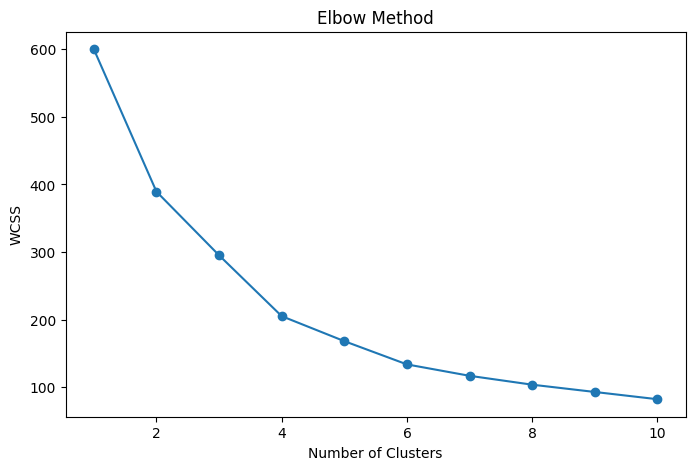

In [18]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11),wcss,marker='o')

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()


In [19]:
model = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

model.fit(X_scaled)


KMeans(n_clusters=5, n_init=10, random_state=42)

In [21]:
joblib.dump(model,"220117.pkl")

['220117.pkl']

In [22]:
df["Cluster"] = model.labels_

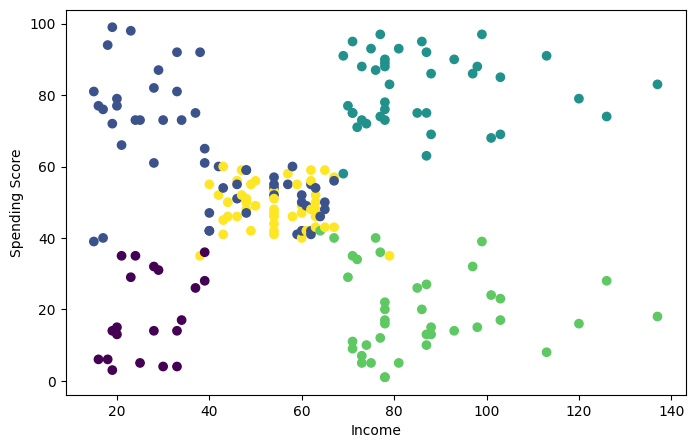

In [23]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Cluster"]
)

plt.xlabel("Income")
plt.ylabel("Spending Score")

plt.show()


In [24]:
custom = pd.read_csv(
"/content/Assignment6_Kmeans/dataset/customer_data.csv"
)

custom

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,20,25,80
1,2,Male,22,30,70
2,3,Female,24,40,60
3,4,Female,26,50,55
4,5,Female,28,60,50
5,6,Female,30,70,45
6,7,Female,32,80,40
7,8,Female,34,90,35
8,9,Male,36,100,30
9,10,Female,40,110,25


In [28]:
custom = custom[scaler.feature_names_in_]
custom_scaled = scaler.transform(custom)

In [29]:
pred = model.predict(custom_scaled)

custom["Cluster"] = pred

custom

/tmp/ipykernel_1362/2856459521.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  custom["Cluster"] = pred


,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,20,25,80,1
1,22,30,70,1
2,24,40,60,1
3,26,50,55,1
4,28,60,50,1
5,30,70,45,1
6,32,80,40,3
7,34,90,35,3
8,36,100,30,3
9,40,110,25,3


Cluster 0 represents customers with high spending behavior.

Cluster 1 represents moderate income and moderate spending customers.

Cluster 2 represents lower spending customers.

Cluster 3 represents high income customers.

Cluster 4 represents premium customers with high income and spending.